In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
torch.autograd.set_detect_anomaly(True)


In [20]:
# Load dataset

df = pd.read_csv("sample_data/global_climate_energy_2020_2024.csv")

print(df.shape)
df.head()

(36540, 10)


,date,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
0,2020-01-01,Germany,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93
1,2020-01-02,Germany,28.38,37.94,606.05,4166.64,5.63,86.26,78.27,110.40
2,2020-01-03,Germany,28.74,57.67,268.72,4503.80,14.20,75.92,48.96,173.58
3,2020-01-04,Germany,26.66,51.34,167.32,3259.13,13.84,63.15,97.42,89.13
4,2020-01-05,Germany,26.81,65.38,393.89,7023.72,6.93,76.02,81.89,40.60


# DATE FEATURES

In [21]:
df['date'] = pd.to_datetime(df['date'])

# Sort chronologically
df = df.sort_values('date').reset_index(drop=True)

# Extract features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter

# --------------------------------------------
# Cyclical Scaling
# --------------------------------------------

# Month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Day of week
df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

# Quarter
df['quarter_sin'] = np.sin(2 * np.pi * df['quarter'] / 4)
df['quarter_cos'] = np.cos(2 * np.pi * df['quarter'] / 4)

# Drop raw cyclical columns
df.drop(columns=['month','dayofweek', 'quarter', 'date'], inplace=True)

print(df.shape)
df.head()

(36540, 16)


,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price,year,month_sin,month_cos,dow_sin,dow_cos,quarter_sin,quarter_cos
0,Germany,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93,2020,0.5,0.866025,0.974928,-0.222521,1.0,6.123234e-17
1,China,22.67,69.96,674.21,4239.03,9.97,67.81,43.09,96.68,2020,0.5,0.866025,0.974928,-0.222521,1.0,6.123234e-17
2,Australia,30.61,55.17,334.08,5592.89,8.90,61.41,73.01,106.54,2020,0.5,0.866025,0.974928,-0.222521,1.0,6.123234e-17
3,Netherlands,23.57,80.03,164.82,11560.13,14.29,68.54,43.86,155.06,2020,0.5,0.866025,0.974928,-0.222521,1.0,6.123234e-17
4,India,12.65,81.06,261.87,9749.27,7.86,88.20,47.31,184.10,2020,0.5,0.866025,0.974928,-0.222521,1.0,6.123234e-17


# ENCODE CATEGORICAL VARIABLES

In [22]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df_encoded.shape)

Categorical columns:
['country']
(36540, 34)


In [23]:
# ============================================
# DEFINE TARGET VARIABLE
# ============================================

TARGET_COL = "energy_consumption"

print("Target column:", TARGET_COL)

Target column: energy_consumption


# SPLIT DATA

In [24]:
train_size = int(len(df_encoded) * 0.70)
val_size = int(len(df_encoded) * 0.15)

train_df = df_encoded.iloc[:train_size]
val_df = df_encoded.iloc[train_size:train_size + val_size]
test_df = df_encoded.iloc[train_size + val_size:]

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (25578, 34)
Validation: (5481, 34)
Test: (5481, 34)


#
# SCALING
#

In [25]:
X_train = train_df.drop(columns=[TARGET_COL]).copy()
y_train = train_df[[TARGET_COL]]

X_val = val_df.drop(columns=[TARGET_COL]).copy()
y_val = val_df[[TARGET_COL]]

X_test = test_df.drop(columns=[TARGET_COL]).copy()
y_test = test_df[[TARGET_COL]]

# --------------------------------------------
# Cyclical columns
# --------------------------------------------

cyclic_cols = [
    'month_sin',
    'month_cos',
    'dow_sin',
    'dow_cos',
    'quarter_sin',
    'quarter_cos'
]

# --------------------------------------------
# Columns to standard scale
# --------------------------------------------

scale_cols = [
    col for col in X_train.columns
    if col not in cyclic_cols
]

print("Scaled columns:")
print(scale_cols)

print("\nNon-scaled cyclical columns:")
print(cyclic_cols)

# --------------------------------------------
# Standard scale ONLY non-cyclic columns
# --------------------------------------------

feature_scaler = MinMaxScaler(feature_range=(-1, 1))

X_train_scaled_part = feature_scaler.fit_transform(
    X_train[scale_cols]
)

X_val_scaled_part = feature_scaler.transform(
    X_val[scale_cols]
)

X_test_scaled_part = feature_scaler.transform(
    X_test[scale_cols]
)

# Convert back to DataFrames

X_train_scaled_part = pd.DataFrame(
    X_train_scaled_part,
    columns=scale_cols,
    index=X_train.index
)

X_val_scaled_part = pd.DataFrame(
    X_val_scaled_part,
    columns=scale_cols,
    index=X_val.index
)

X_test_scaled_part = pd.DataFrame(
    X_test_scaled_part,
    columns=scale_cols,
    index=X_test.index
)

# --------------------------------------------
# Add cyclical features back WITHOUT scaling
# --------------------------------------------

X_train_scaled = pd.concat(
    [
        X_train_scaled_part,
        X_train[cyclic_cols]
    ],
    axis=1
)

X_val_scaled = pd.concat(
    [
        X_val_scaled_part,
        X_val[cyclic_cols]
    ],
    axis=1
)

X_test_scaled = pd.concat(
    [
        X_test_scaled_part,
        X_test[cyclic_cols]
    ],
    axis=1
)

# --------------------------------------------
# Preserve same column order
# --------------------------------------------

X_train_scaled = X_train_scaled[X_train.columns]
X_val_scaled = X_val_scaled[X_train.columns]
X_test_scaled = X_test_scaled[X_train.columns]

# --------------------------------------------
# Scale target
# --------------------------------------------

target_scaler = MinMaxScaler(feature_range=(-1, 1.0))

y_train_scaled = target_scaler.fit_transform(y_train)

y_val_scaled = target_scaler.transform(y_val)

y_test_scaled = target_scaler.transform(y_test)

print("\nFinal train shape:", X_train_scaled.shape)

Scaled columns:
['avg_temperature', 'humidity', 'co2_emission', 'renewable_share', 'urban_population', 'industrial_activity_index', 'energy_price', 'year', 'country_Brazil', 'country_Canada', 'country_China', 'country_France', 'country_Germany', 'country_India', 'country_Indonesia', 'country_Italy', 'country_Japan', 'country_Mexico', 'country_Netherlands', 'country_Norway', 'country_Poland', 'country_South Africa', 'country_Spain', 'country_Sweden', 'country_Turkey', 'country_United Kingdom', 'country_United States']

Non-scaled cyclical columns:
['month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'quarter_sin', 'quarter_cos']

Final train shape: (25578, 33)


In [26]:
X_train_scaled.describe()

,avg_temperature,humidity,co2_emission,renewable_share,urban_population,industrial_activity_index,energy_price,year,month_sin,month_cos,...,country_Mexico,country_Netherlands,country_Norway,country_Poland,country_South Africa,country_Spain,country_Sweden,country_Turkey,country_United Kingdom,country_United States
count,25578.000000,25578.000000,25578.000000,25578.000000,25578.000000,25578.000000,25578.000000,25578.000000,2.557800e+04,2.557800e+04,...,25578.000000,25578.000000,25578.000000,25578.000000,25578.000000,25578.000000,25578.000000,25578.000000,25578.000000,25578.000000
mean,0.001988,-0.004261,-0.166790,-0.194503,0.000037,0.004934,0.002006,-0.143170,8.308171e-02,-2.716672e-02,...,-0.899992,-0.899992,-0.899992,-0.899992,-0.899992,-0.899992,-0.899992,-0.899992,-0.899992,-0.899992
std,0.415413,0.575993,0.494604,0.397639,0.577328,0.579002,0.577765,0.687125,7.005643e-01,7.082428e-01,...,0.435915,0.435915,0.435915,0.435915,0.435915,0.435915,0.435915,0.435915,0.435915,0.435915
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000e+00,-1.000000e+00,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-0.307374,-0.503333,-0.583205,-0.487156,-0.503333,-0.491000,-0.502000,-1.000000,-5.000000e-01,-8.660254e-01,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.030655,-0.005000,-0.214899,-0.207339,0.004000,0.002833,0.000176,-0.333333,1.224647e-16,-1.836970e-16,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
75%,0.308202,0.495250,0.218021,0.082569,0.505333,0.509667,0.508794,0.333333,8.660254e-01,5.000000e-01,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [27]:
y_train_scaled[2]

array([-0.38771362])

In [28]:
print('X_train_scaled.shape:', X_train_scaled.shape)
print('X_val_scaled.shape:', X_val_scaled.shape)
print('X_test_scaled.shape:', X_test_scaled.shape)
print()
print('y_train_scaled.shape:', y_train_scaled.shape)
print('y_val_scaled.shape:', y_val_scaled.shape)
print('y_test_scaled.shape:', y_test_scaled.shape)


X_train_scaled.shape: (25578, 33)
X_val_scaled.shape: (5481, 33)
X_test_scaled.shape: (5481, 33)

y_train_scaled.shape: (25578, 1)
y_val_scaled.shape: (5481, 1)
y_test_scaled.shape: (5481, 1)


# PyTorch Dataset

In [29]:
class EnergyDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [30]:
batch_size = 128

train_dataset = EnergyDataset(X_train_scaled, y_train_scaled)
val_dataset = EnergyDataset(X_val_scaled, y_val_scaled)
test_dataset = EnergyDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

# ENERGY-BASED MODEL


In [46]:

class EnergyBasedModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, dropout_rate):

        super().__init__()

        self.energy_net = nn.Sequential(

            nn.Linear(input_dim + 1, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim, hidden_dim // 2),
            # nn.BatchNorm1d(hidden_dim // 2),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(hidden_dim//2, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim, hidden_dim//2),
            # nn.BatchNorm1d(hidden_dim // 2),
            nn.LeakyReLU(negative_slope=0.01),

            # nn.Linear(hidden_dim//2, hidden_dim//2),
            # nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            # nn.BatchNorm1d(hidden_dim // 4),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim // 4, 1)
        )

    def forward(self, x, y):
        # return self.model(x)
        # Concatenate x and candidate y
        combined = torch.cat([x, y], dim=1)

        # Compute energy
        energy = self.energy_net(combined)

        return energy.squeeze(-1)


model = EnergyBasedModel(input_dim=X_train_scaled.shape[1], hidden_dim=126, dropout_rate=0.05)

# OPTIMIZER


In [47]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# CONTRASTIVE LOSS

In [48]:
# def energy_loss(
#     positive_energy,
#     negative_energy,
#     margin=1.0
# ):

#     loss = torch.mean(
#         torch.relu(
#             margin +
#             positive_energy -
#             negative_energy
#         )
#     )

#     return loss

criterion = nn.MarginRankingLoss(margin=1.0)

# TRAINING

In [49]:
# Define the device for training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move the model to the defined device
model.to(device);

Using device: cuda


In [57]:
# ============================================
# CELL 13 — TRAINING LOOP
# ============================================

epochs = 700

best_val_loss = np.inf
best_model_state = None

patience = 100
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):

    # ----------------------------------------
    # TRAINING
    # ----------------------------------------

    model.train()

    running_train_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device) # Move X_batch to device
        y_batch = y_batch.to(device) # Move y_batch to device

        optimizer.zero_grad()

        # ------------------------------------
        # Positive samples
        # ------------------------------------

        positive_energy = model(
            X_batch,
            y_batch
        )

        # ------------------------------------
        # Negative samples
        # Add random noise to targets
        # ------------------------------------

        noise = torch.randn_like(y_batch) * 0.5

        y_negative = y_batch + noise
        # y_negative = torch.clamp(y_negative, min=-1.0, max=1.0)

        negative_energy = model(
            X_batch,
            y_negative
        )

        # ------------------------------------
        # Loss
        # ------------------------------------

        target = -torch.ones_like(positive_energy)

        loss = criterion(
            positive_energy,
            negative_energy,
            target
        )

        # torch.nn.utils.clip_grad_norm_(
        #     model.parameters(),
        #     max_norm=1.0
        # )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # ----------------------------------------
    # VALIDATION
    # ----------------------------------------

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            positive_energy = model(
                X_batch,
                y_batch
            )

            noise = torch.randn_like(y_batch) * 0.5

            y_negative = y_batch + noise
            # y_negative = torch.clamp(y_negative, min=-1.0, max=1.0)

            negative_energy = model(
                X_batch,
                y_negative
            )

            target = -torch.ones_like(positive_energy)

            loss = criterion(
                positive_energy,
                negative_energy,
                target
            )

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    # ----------------------------------------
    # EARLY STOPPING
    # ----------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = model.state_dict()

        patience_counter = 0

    else:

        patience_counter += 1

    if patience_counter >= patience:

        print("Early stopping triggered")

        break

# Restore best weights
model.load_state_dict(best_model_state)

Epoch [1/700] Train Loss: 0.5901 Val Loss: 0.7852
Epoch [2/700] Train Loss: 0.5903 Val Loss: 0.7811
Epoch [3/700] Train Loss: 0.5930 Val Loss: 0.7956
Epoch [4/700] Train Loss: 0.5990 Val Loss: 0.7946
Epoch [5/700] Train Loss: 0.5991 Val Loss: 0.7789
Epoch [6/700] Train Loss: 0.5906 Val Loss: 0.7802
Epoch [7/700] Train Loss: 0.5971 Val Loss: 0.7924
Epoch [8/700] Train Loss: 0.5888 Val Loss: 0.7774
Epoch [9/700] Train Loss: 0.5875 Val Loss: 0.7850
Epoch [10/700] Train Loss: 0.5823 Val Loss: 0.7665
Epoch [11/700] Train Loss: 0.5891 Val Loss: 0.8051
Epoch [12/700] Train Loss: 0.5949 Val Loss: 0.7928
Epoch [13/700] Train Loss: 0.5975 Val Loss: 0.8058
Epoch [14/700] Train Loss: 0.5823 Val Loss: 0.7915
Epoch [15/700] Train Loss: 0.5976 Val Loss: 0.7828
Epoch [16/700] Train Loss: 0.5858 Val Loss: 0.7783
Epoch [17/700] Train Loss: 0.5889 Val Loss: 0.7968
Epoch [18/700] Train Loss: 0.5841 Val Loss: 0.8130
Epoch [19/700] Train Loss: 0.5913 Val Loss: 0.7636
Epoch [20/700] Train Loss: 0.5997 Val Lo

<All keys matched successfully>

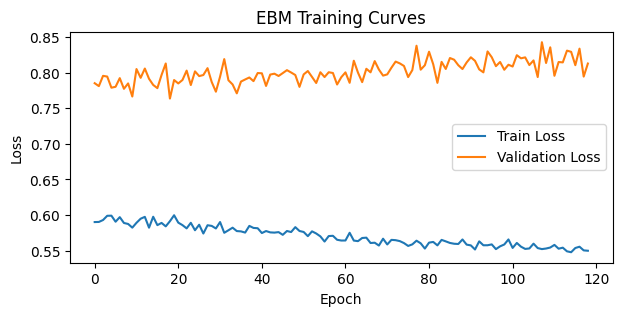

In [58]:
# ============================================
# CELL 14 — LOSS CURVES
# ============================================

plt.figure(figsize=(7, 3))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("EBM Training Curves")

plt.legend()

plt.show()

In [59]:
# ============================================
# CELL 15 — EBM PREDICTION
# ============================================

def predict_ebm(model, X_batch):

    model.eval()

    predictions = []

    with torch.no_grad():

        for x in X_batch:

            x = x.unsqueeze(0)

            # Candidate y values
            y_candidates = torch.linspace(
                -3,
                3,
                200
            ).unsqueeze(1).to(device)

            x_repeated = x.repeat(
                len(y_candidates),
                1
            )

            energies = model(
                x_repeated,
                y_candidates
            )

            best_idx = torch.argmin(energies)

            best_y = y_candidates[best_idx]

            predictions.append(
                best_y.item()
            )

    return np.array(predictions)

In [60]:
# ============================================
# CELL 16 — TEST EVALUATION
# ============================================

X_test_tensor = torch.tensor(
    X_test_scaled.values,
    dtype=torch.float32
).to(device)

y_pred_scaled = predict_ebm(
    model,
    X_test_tensor
)

y_pred_scaled = y_pred_scaled.reshape(-1, 1)

# Inverse transform
y_pred = target_scaler.inverse_transform(
    y_pred_scaled
)

y_true = target_scaler.inverse_transform(
    y_test_scaled
)

# Metrics
mse = mean_squared_error(
    y_true,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_true,
    y_pred
)

r2 = r2_score(
    y_true,
    y_pred
)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

MSE  : 24087824.1740
RMSE : 4907.9348
MAE  : 3911.4409
R²   : -0.8101


In [54]:
y_true

array([[12980.5 ],
       [14250.57],
       [11839.95],
       ...,
       [ 5761.13],
       [ 4495.84],
       [ 6227.33]])

In [55]:
y_pred

array([[12004.1080534 ],
       [ 7256.59351646],
       [ 6352.30479913],
       ...,
       [ 8160.88220585],
       [ 7708.73787512],
       [ 4543.72758793]])